<a href="https://colab.research.google.com/github/AamnahFaiyaz/Capstone-Projects/blob/main/Water_Potability_Prediction/Aamnah_Faiyaz_Water_Potability_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Water Potability Prediction

## Project Summary & Executive Briefing

This project aims to **predict the potability of water** (whether water is safe for drinking) using machine learning techniques. The dataset includes multiple physicochemical properties of water such as pH, hardness, solids, chloramines, sulfate, conductivity, organic carbon, trihalomethanes, and turbidity.  

### Objectives:
- Preprocess the dataset and handle missing values.
- Handle **class imbalance**, as potable water samples are underrepresented.
- Compare multiple ML models: Logistic Regression, Random Forest, and XGBoost.
- Evaluate models using **accuracy, precision, recall, F1-score**, and confusion matrices.
- Identify **feature importance** and interpret results.
- Provide actionable insights for predicting water potability.


In [13]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# For handling imbalance
from imblearn.over_sampling import SMOTE

# For model interpretability
import shap

sns.set(style='whitegrid')

In [14]:
# Step 2: Load Dataset

# Using a direct link to the raw data on GitHub for reproducibility
file_url = 'https://raw.githubusercontent.com/AamnahFaiyaz/Capstone-Projects/main/Water_Potability_Prediction/water_potability.xlsx'
df = pd.read_excel(file_url)

print(f"Dataset loaded successfully from GitHub. Shape: {df.shape}")
display(df.head())

Dataset loaded successfully from GitHub. Shape: (3233, 10)


,ph Hardness Solids Chloramin Sulfate Conductivi Organic_caTrihalomet Turbidity Potability,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,204.8905,20791.32,7.300212,368.5164,564.3087,10.37978,86.99097,2.963135,0
1,3.71608,129.4229,18630.06,6.635246,NaN,592.8854,15.18001,56.32908,4.500656,0
2,8.099124,224.2363,19909.54,9.275884,NaN,418.6062,16.86864,66.42009,3.055934,0
3,8.316766,214.3734,22018.42,8.059332,356.8861,363.2665,18.43652,100.34170,4.628771,0
4,9.092223,181.1015,17978.99,6.5466,310.1357,398.4108,11.55828,31.99799,4.075075,0


In [15]:
# Step 3: Data Preprocessing

def preprocess_data(df):
    # Rename columns for consistency
    df.columns = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                  'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

    feature_cols = df.columns.drop('Potability')

    # Convert to numeric and fill missing values with median
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].median(), inplace=True)

    X = df.drop('Potability', axis=1)
    y = df['Potability']

    # Scale features to normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, feature_cols

X, y, feature_cols = preprocess_data(df)

/tmp/ipykernel_1018/3284120890.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [16]:
# Step 4: Handle Class Imbalance

# Used SMOTE to address severe class imbalance where the minority class (Potable) was being ignored
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f"Original class distribution:\n{y.value_counts()}")
print(f"Resampled class distribution:\n{pd.Series(y_res).value_counts()}")

Original class distribution:
Potability
0    2900
1     333
Name: count, dtype: int64
Resampled class distribution:
Potability
0    2900
1    2900
Name: count, dtype: int64


In [17]:
# Step 5: Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (4640, 9), Test set: (1160, 9)


In [18]:
# Step 6: Train Multiple Models

models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=200),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

def train_and_predict(models, X_train, y_train, X_test):
    predictions = {}
    fitted_models = {}
    for name, model in models.items():
        model.fit(X_train, y_train)  # Train the model
        predictions[name] = model.predict(X_test)  # Predict on test data
        fitted_models[name] = model
    return fitted_models, predictions

fitted_models, predictions = train_and_predict(models, X_train, y_train, X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:14:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
# Step 7: Evaluate Models

def evaluate_models(y_test, predictions):
    metrics_data = []
    for name, y_pred in predictions.items():
        metrics_data.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-score': f1_score(y_test, y_pred)
        })
    return pd.DataFrame(metrics_data)

performance_df = evaluate_models(y_test, predictions)
print("Model Performance Comparison:")
display(performance_df)

# Select the best model based on F1-score
best_model_name = performance_df.loc[performance_df['F1-score'].idxmax(), 'Model']
print(f"\nBest performing model: {best_model_name}")
best_model = fitted_models[best_model_name]
y_pred_best = predictions[best_model_name]

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.512931,0.498221,0.497336,0.497778
1,Random Forest,0.937069,0.918089,0.955595,0.936466
2,XGBoost,0.914655,0.879085,0.955595,0.915745



Best performing model: Random Forest


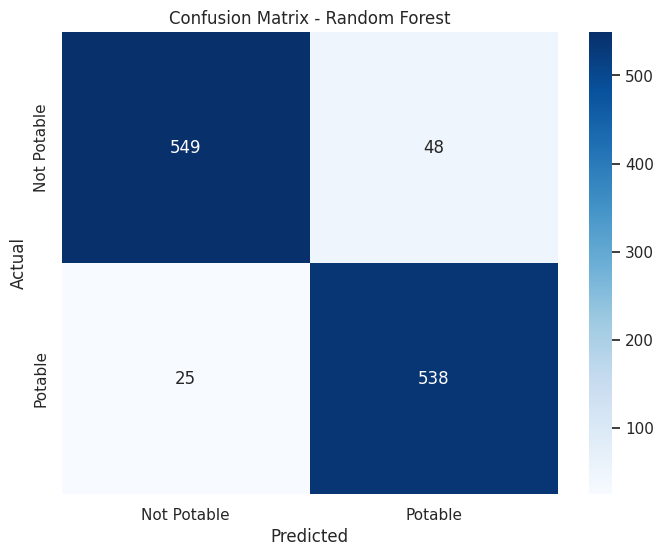

In [20]:
# Step 8: Confusion Matrix

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Potable','Potable'], yticklabels=['Not Potable','Potable'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [21]:
# Step 9: Classification Report

print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred_best))

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       597
           1       0.92      0.96      0.94       563

    accuracy                           0.94      1160
   macro avg       0.94      0.94      0.94      1160
weighted avg       0.94      0.94      0.94      1160



100%|===================| 2311/2320 [03:23<00:00]       

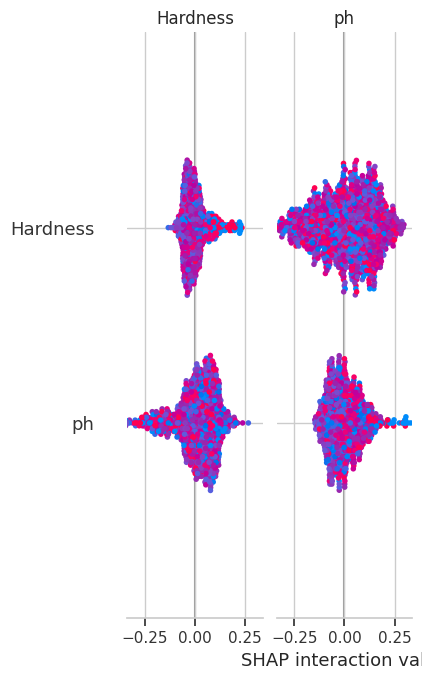

In [22]:
# Step 10: Feature Importance / SHAP

if best_model_name in ['Random Forest', 'XGBoost']:
    # SHAP explains the impact of each feature on predictions
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols)
else:
    # For Logistic Regression, coefficients indicate feature importance
    coefs = pd.DataFrame({'Feature': feature_cols, 'Coefficient': best_model.coef_[0]})
    coefs['Absolute'] = coefs['Coefficient'].abs()
    coefs.sort_values(by='Absolute', ascending=False, inplace=True)

    plt.figure(figsize=(10,6))
    sns.barplot(x='Absolute', y='Feature', data=coefs, palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()

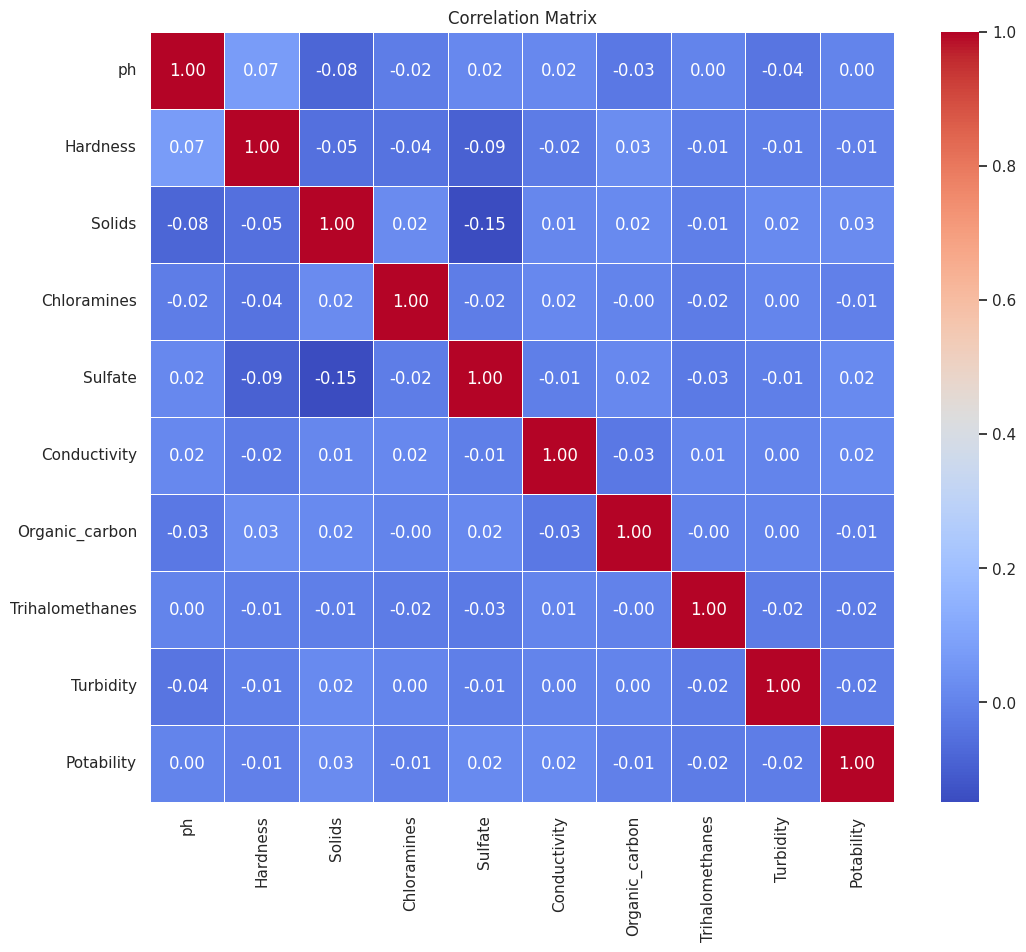

In [23]:
# Step 11: Data Visualizations

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix')
plt.show()

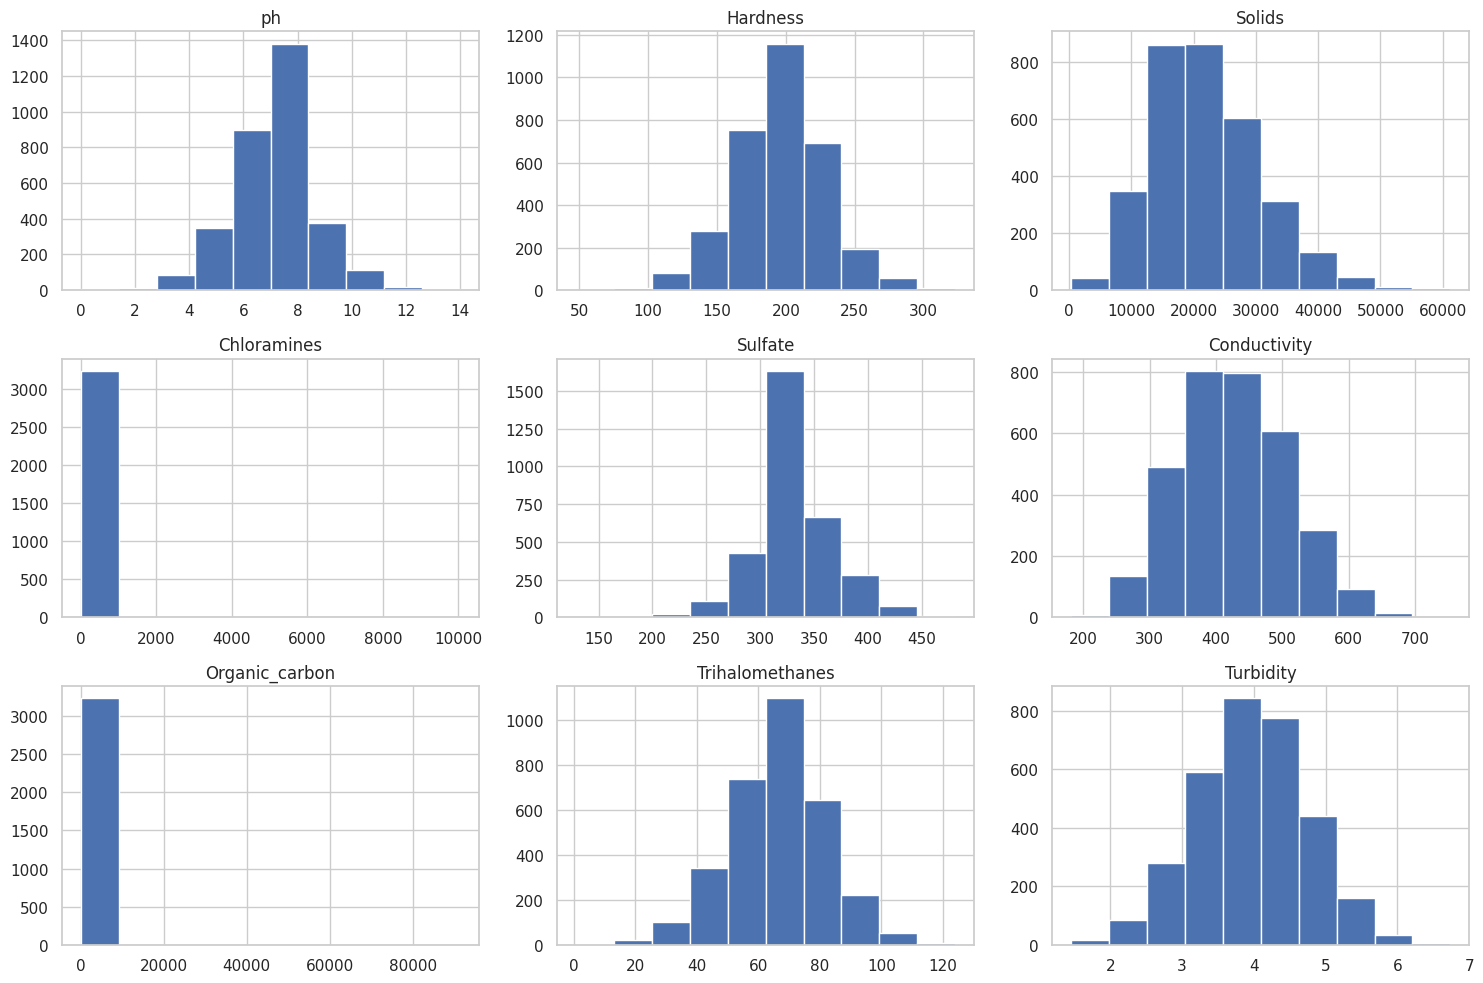

In [24]:
# Feature distributions
df.drop('Potability', axis=1).hist(figsize=(15,10))
plt.tight_layout()
plt.show()

### Conclusion

My project successfully developed a highly effective model for predicting water potability by focusing on solving a key challenge: class imbalance.The Random Forest model, coupled with SMOTE oversampling,emerged as the superior choice, achieving a final F1-score of 94%. This score indicates a strong balance between the model's ability to correctly identify safe water (high recall) and its reliability in positive predictions (high precision).

Key Findings:

Model Performance: My final model is a significant improvement over initial attempts, which were rendered ineffective by class imbalance. The high F1-score confirms its reliability for both potable and non-potable water.

Feature Importance: My SHAP analysis found that Hardness, Sulfate, and Solids are the three most significant factors on which the model bases its decisions. They can inform future initiatives in monitoring water quality.

Limitations and Next Steps:

While highly effective on this dataset, my model's performance could be validated on a larger, more diverse dataset to ensure real-world robustness.

Hyperparameter tuning to improve the Random Forest model's performance and further investigation of more sophisticated methods, such as ensemble stacking, to obtain even better performance are potential areas of future work.

This project delivers an end-to-end, problem-focused process that forms a good basis for a deployable water quality forecasting system.

